In [1]:
from sympy.abc import a
import numpy as np
import matplotlib.pyplot as plt

In [8]:
def fig_decor(ax):
    plt.xlabel('$x$ (number of chickens)')
    plt.ylabel('$x$ (number of rabbits)')
    plt.axis('scaled')
    ax.set_xlim([0, 120])  # 设置 x 轴范围
    ax.set_ylim([0, 80])  # 设置 y 轴范围
    plt.xticks(np.arange(0, 120 + 1, step=10))  # 设置 x 轴刻度
    plt.yticks(np.arange(0, 80 + 1, step=10))  # 设置 y 轴刻度
    plt.minorticks_on() #开启小刻度
    ax.grid(which = 'minor',linestyle = ':',linewidth = '0.5',color = '0.8')
    ax.spines['top'].set_visible(False)  # 隐藏上边框
    ax.spines['right'].set_visible(False)  # 隐藏右边框
    ax.spines['bottom'].set_visible(False)  # 隐藏下边框
    ax.spines['left'].set_visible(False)  # 隐藏左边框
    ax.grid(linestyle='--', linewidth=0.25, color=[0.5, 0.5, 0.5])  # 设置主网格

In [9]:
num_chickens = np.array([32,110,71,79,45,20,56,55,87,68,87,63,31,88])
num_rabbits  = np.array([22,53,39,40,25,15,34,34,52,41,43,33,24,52])

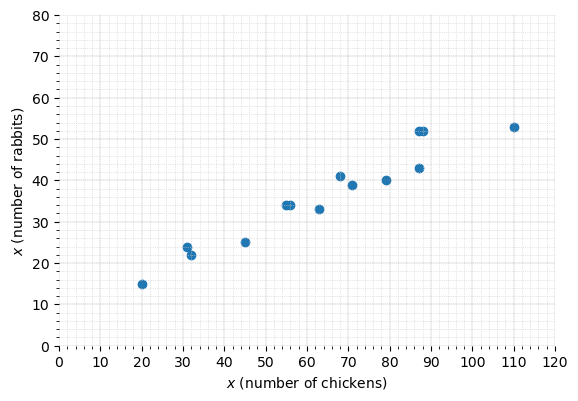

In [10]:
fig,ax = plt.subplots()
plt.scatter(num_chickens,num_rabbits)
fig_decor(ax)

In [11]:
from sympy import *

y_pred = a*num_chickens

In [12]:
y_pred

array([32*a, 110*a, 71*a, 79*a, 45*a, 20*a, 56*a, 55*a, 87*a, 68*a, 87*a,
       63*a, 31*a, 88*a], dtype=object)

In [13]:
f_a_SSE = np.sum((num_rabbits - y_pred)**2) #误差平方和 Sum of Squared Errors
f_a_SSE = simplify(f_a_SSE) #简化表达式
f_a_SSE

65428*a**2 - 72228*a + 20179

In [18]:
a_array = np.linspace(0,1,51)

In [19]:
f_a_SSE_fcn = lambdify(a,f_a_SSE)
SSE_array = f_a_SSE_fcn(a_array)

In [25]:
df_da_SSE = diff(f_a_SSE,a)
print(df_da_SSE) #一阶导数

130856*a - 72228


In [26]:
a_star_only = solve(df_da_SSE,a)#默认表达式的取值为0,直接求解
print(a_star_only)

[18057/32714]


In [32]:
a_star_only = a_star_only.evalf()#将精确表达式转换为浮点数,注意这里依旧是sympy
a_star_only

0.551965519349514

In [33]:
SSE_min = f_a_SSE_fcn(a_star_only) #计算最小的sse

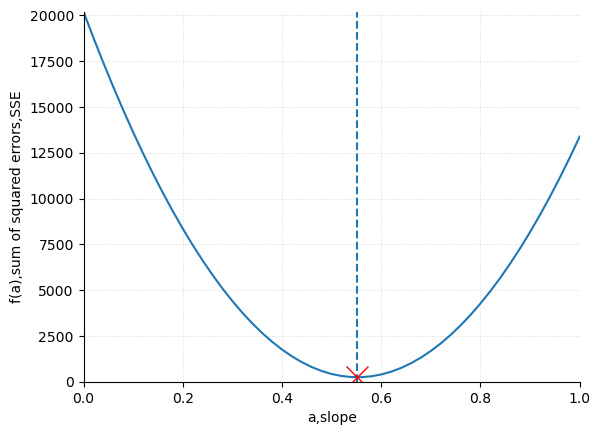

In [35]:
fig,ax = plt.subplots()

plt.plot(a_array,SSE_array)
plt.axvline(x = a_star_only,linestyle = '--')
plt.plot(a_star_only,SSE_min,'rx',markersize = 16)

plt.xlabel('a,slope')
plt.ylabel('f(a),sum of squared errors,SSE')

ax.set_xlim([a_array.min(),a_array.max()])
ax.set_ylim([0,SSE_array.max()])

ax.grid(linestyle=':', linewidth='0.5', color=[0.8, 0.8, 0.8])  # 设置网格

ax.spines['top'].set_visible(False)  # 隐藏上边框
ax.spines['right'].set_visible(False)  # 隐藏右边框

In [45]:
def plot_square(x,y1,y2):
    if y2 > y1: #确保y2是较小值
        temp = y2
        y2 = y1
        y1 = temp

    d = y1 - y2

    plt.fill(np.vstack((x,x+d,x+d,x)),
             np.vstack((y2,y2,y1,y1)),
             facecolor = 'b',edgecolor = 'none',
             alpha = 0.3
            )

In [46]:
x_array = np.linspace(0,150,10)[:,None]#增加一个维度

In [47]:
y_pred = a_star_only*x_array

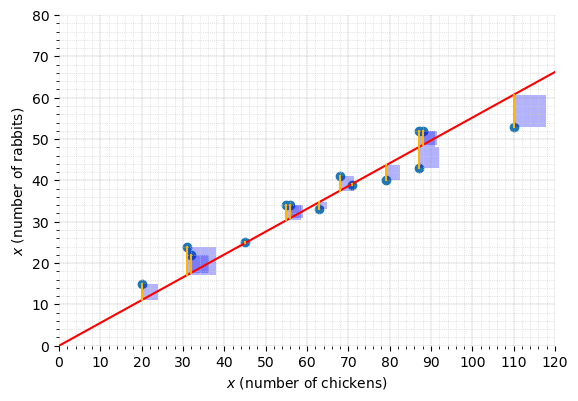

In [50]:
fig,ax = plt.subplots()

plt.plot(x_array,y_pred,color = 'r')
plt.scatter(num_chickens,num_rabbits)

num_rabbits_predicted = a_star_only*num_chickens

plt.plot(np.vstack((num_chickens,num_chickens)),
         np.vstack((num_rabbits,num_rabbits_predicted)),
         color = np.array([255,182,0])/255)

for i in range(0,len(num_rabbits_predicted)):
    plot_square(num_chickens[i],num_rabbits[i],num_rabbits_predicted[i])

fig_decor(ax)

In [51]:
import numpy as np
import matplotlib.pyplot as plt
from sympy.abc import a,b
from sympy import *

In [53]:
def fig_decor(ax):
    plt.xlabel('$x$ (number of chickens)')
    plt.ylabel('$x$ (number of rabbits)')
    plt.axis('scaled')
    ax.set_xlim([0, 120])  # 设置 x 轴范围
    ax.set_ylim([0, 80])  # 设置 y 轴范围
    plt.xticks(np.arange(0, 120 + 1, step=10))  # 设置 x 轴刻度
    plt.yticks(np.arange(0, 80 + 1, step=10))  # 设置 y 轴刻度
    plt.minorticks_on() #开启小刻度
    ax.grid(which = 'minor',linestyle = ':',linewidth = '0.5',color = '0.8')
    ax.spines['top'].set_visible(False)  # 隐藏上边框
    ax.spines['right'].set_visible(False)  # 隐藏右边框
    ax.spines['bottom'].set_visible(False)  # 隐藏下边框
    ax.spines['left'].set_visible(False)  # 隐藏左边框
    ax.grid(linestyle='--', linewidth=0.25, color=[0.5, 0.5, 0.5])  # 设置主网格

num_chickens = np.array([32,110,71,79,45,20,56,55,87,68,87,63,31,88])
num_rabbits  = np.array([22,53,39,40,25,15,34,34,52,41,43,33,24,52])

In [54]:
y_pred = a*num_chickens + b
f_ab_SSE = np.sum((num_rabbits - y_pred)**2)
f_ab_SSE = simplify(f_ab_SSE) #简化表达式
print(f_ab_SSE)

65428*a**2 + 1784*a*b - 72228*a + 14*b**2 - 1014*b + 20179


In [55]:
a_array = np.linspace(0,0.9,40)
b_array = np.linspace(-20,36,40)
aa,bb = np.meshgrid(a_array,b_array)
f_ab_SSE_fcn = lambdify((a,b),f_ab_SSE)
SSE_matrix = f_ab_SSE_fcn(aa,bb)

In [56]:
df_da_SSE = diff(f_ab_SSE,a)
print(df_da_SSE)

130856*a + 1784*b - 72228


In [57]:
df_db_SSE = diff(f_ab_SSE,b)
print(df_db_SSE)

1784*a + 28*b - 1014


In [59]:
#不是自动求偏微分,已经给了两个公式和两个未知量,自动按照公式的值为0求a和b
sol = solve([df_da_SSE,df_db_SSE],[a,b])
print(sol)

{a: 513/1157, b: 18429/2314}


In [61]:
a_star = sol[a]
b_star = sol[b]
a_star = a_star.evalf()
b_star = b_star.evalf()
print(a_star)
print(b_star)

0.443388072601556
7.96413137424373


In [62]:
SSE_min = f_ab_SSE_fcn(a_star,b_star)
print(SSE_min)

128.668539325841


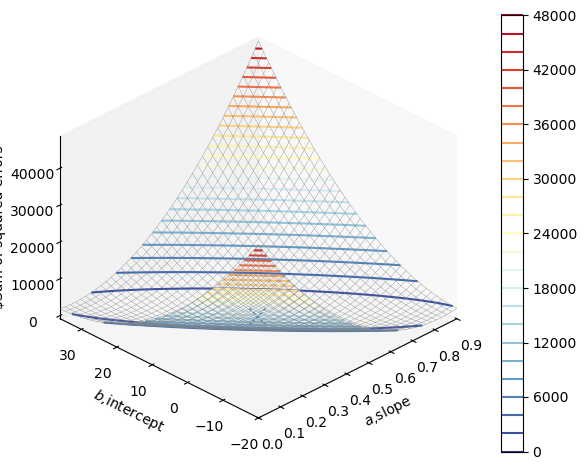

In [66]:
fig,ax = plt.subplots(subplot_kw = {'projection':'3d'})
ax.plot_wireframe(aa,bb,SSE_matrix,color = '0.5',linewidth = 0.25)
plt.plot(a_star,b_star,SSE_min,marker = 'x',markersize = 12)
colorbar = ax.contour(aa,bb,SSE_matrix,30,cmap = 'RdYlBu_r') #30表示找30个区间,然后画线
fig.colorbar(colorbar,ax = ax)
ax.set_proj_type('ortho')
ax.set_xlabel('$a$,slope')
ax.set_ylabel('$b$,intercept')
ax.set_zlabel('$Sum of squared errors')
plt.tight_layout()
ax.set_xlim(aa.min(), aa.max())  # 设置x轴范围为网格范围
ax.set_ylim(bb.min(), bb.max())  # 设置y轴范围为网格范围
ax.view_init(azim=-135, elev=30)  # 设置视角角度
ax.grid(False)  # 关闭网格
plt.show()  # 显示图形

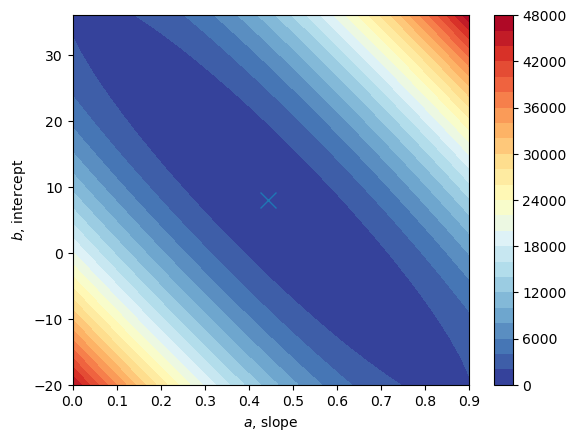

In [68]:
fig,ax = plt.subplots()
colorbar = ax.contourf(aa,bb,SSE_matrix,30,cmap = 'RdYlBu_r')
fig.colorbar(colorbar,ax = ax)
plt.plot(a_star,b_star,marker = 'x',markersize = 12)
ax.set_xlim(aa.min(), aa.max())  # 设置x轴范围为网格范围
ax.set_ylim(bb.min(), bb.max())  # 设置y轴范围为网格范围
ax.set_xlabel('$a$, slope')  # 设置x轴标签
ax.set_ylabel('$b$, intercept')  # 设置y轴标签
plt.show()  # 显示图形

In [70]:
def plot_square(x,y1,y2):
    if y2 > y1:
        temp = y2
        y2 = y1
        y1 = temp
    d = y1 - y2
    plt.fill(np.vstack((x,x+d,x+d,x)),
            np.vstack((y2,y2,y1,y1)),
                     facecolor = 'b',edgecolor = 'none',alpha = 0.3)

In [71]:
x_array = np.linspace(0,150,10)[:,None]
y_pred = a_star*x_array + b_star #star表示*,表示最优解

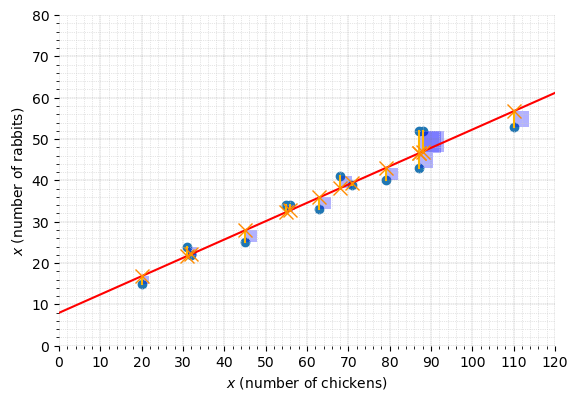

In [73]:
fig,ax = plt.subplots()
plt.plot(x_array,y_pred,color = 'r')
plt.scatter(num_chickens,num_rabbits)
num_rabbits_predicted = a_star * num_chickens + b_star
plt.plot(np.vstack((num_chickens,num_chickens)),
         np.vstack((num_rabbits,num_rabbits_predicted)),
         color = np.array([255,182,0])/255)#两个数组的形状一致即可,对应xy值找点,形状与点无关
plt.plot(num_chickens,num_rabbits_predicted,
         linestyle = 'None',marker = 'x',
         markerfacecolor = 'darkorange',markeredgecolor = 'darkorange',
         markersize = 10)

for i in range(0,len(num_rabbits_predicted)):
    plot_square(num_chickens[i],num_rabbits[i],num_rabbits_predicted[i])
fig_decor(ax)

In [74]:
import numpy as np
import matplotlib.pyplot as plt

In [75]:
def fig_decor(ax):
    plt.xlabel('$x$ (number of chickens)')
    plt.ylabel('$x$ (number of rabbits)')
    plt.axis('scaled')
    ax.set_xlim([0, 120])  # 设置 x 轴范围
    ax.set_ylim([0, 80])  # 设置 y 轴范围
    plt.xticks(np.arange(0, 120 + 1, step=10))  # 设置 x 轴刻度
    plt.yticks(np.arange(0, 80 + 1, step=10))  # 设置 y 轴刻度
    plt.minorticks_on() #开启小刻度
    ax.grid(which = 'minor',linestyle = ':',linewidth = '0.5',color = '0.8')
    ax.spines['top'].set_visible(False)  # 隐藏上边框
    ax.spines['right'].set_visible(False)  # 隐藏右边框
    ax.spines['bottom'].set_visible(False)  # 隐藏下边框
    ax.spines['left'].set_visible(False)  # 隐藏左边框
    ax.grid(linestyle='--', linewidth=0.25, color=[0.5, 0.5, 0.5])  # 设置主网格

num_chickens = np.array([32,110,71,79,45,20,56,55,87,68,87,63,31,88])
num_rabbits  = np.array([22,53,39,40,25,15,34,34,52,41,43,33,24,52])

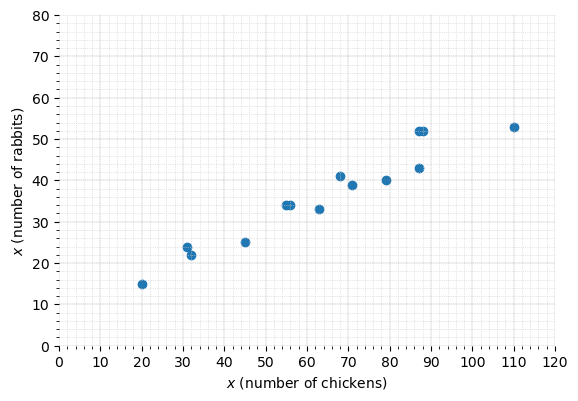

In [76]:
fig,ax = plt.subplots()
plt.scatter(num_chickens,num_rabbits)
fig_decor(ax)

In [77]:
x_array = np.linspace(0,150,10)[:,None]
x = num_chickens[:,None]
y = num_rabbits[:,None]

In [78]:
a_star_only = np.linalg.inv(x.T @ x) @x.T @ y
y_pred = a_star_only * x_array

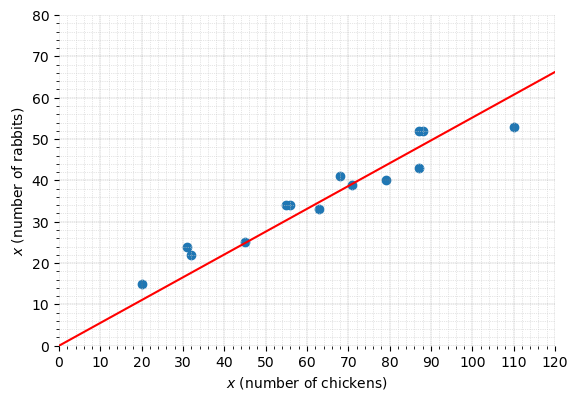

In [80]:
fig,ax = plt.subplots()
plt.plot(x_array,y_pred,color = 'r')
plt.scatter(num_chickens,num_rabbits)
fig_decor(ax)

In [82]:
X = np.hstack((np.ones_like(x),x))
sol = np.linalg.inv(X.T @ X)@X.T @ y

In [83]:
a_star_ = sol[1]
b_star_ = sol[0]

In [85]:
a_star,b_star = np.polyfit(num_chickens,num_rabbits,1)#多项式拟合,1表示一次多项式(直线)
print(a_star_)
print(b_star_)
print(a_star)
print(b_star)

[0.44338807]
[7.96413137]
0.44338807260155577
7.964131374243722


In [87]:
y_pred = a_star*x_array + b_star

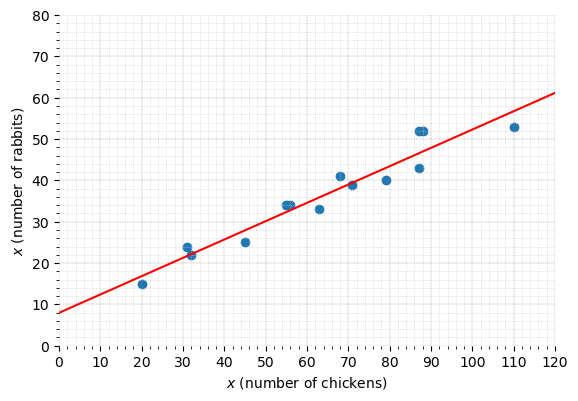

In [88]:
fig,ax = plt.subplots()
plt.plot(x_array,y_pred,color = 'r')
plt.scatter(num_chickens,num_rabbits)
fig_decor(ax)

In [89]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [90]:
def fig_decor(ax):
    plt.xlabel('$x$ (number of chickens)')
    plt.ylabel('$x$ (number of rabbits)')
    plt.axis('scaled')
    ax.set_xlim([0, 120])  # 设置 x 轴范围
    ax.set_ylim([0, 80])  # 设置 y 轴范围
    plt.xticks(np.arange(0, 120 + 1, step=10))  # 设置 x 轴刻度
    plt.yticks(np.arange(0, 80 + 1, step=10))  # 设置 y 轴刻度
    plt.minorticks_on() #开启小刻度
    ax.grid(which = 'minor',linestyle = ':',linewidth = '0.5',color = '0.8')
    ax.spines['top'].set_visible(False)  # 隐藏上边框
    ax.spines['right'].set_visible(False)  # 隐藏右边框
    ax.spines['bottom'].set_visible(False)  # 隐藏下边框
    ax.spines['left'].set_visible(False)  # 隐藏左边框
    ax.grid(linestyle='--', linewidth=0.25, color=[0.5, 0.5, 0.5])  # 设置主网格

num_chickens = np.array([32,110,71,79,45,20,56,55,87,68,87,63,31,88])
num_rabbits  = np.array([22,53,39,40,25,15,34,34,52,41,43,33,24,52])

In [92]:
sigma_X = num_chickens.std(ddof = 1)
sigma_Y = num_rabbits.std(ddof = 1)
rho_XY = np.corrcoef(num_chickens,num_rabbits)[1][0]
mean_X = num_chickens.mean()
mean_Y = num_rabbits.mean()

In [93]:
a = rho_XY * sigma_Y/sigma_X
b = -a * mean_X + mean_Y

In [94]:
print('=====Slopa,a=====')
print(a)
print('=====Intercept,b=====')
print(b)

=====Slopa,a=====
0.44338807260155577
=====Intercept,b=====
7.964131374243731


In [95]:
x_array = np.linspace(0,120,20)

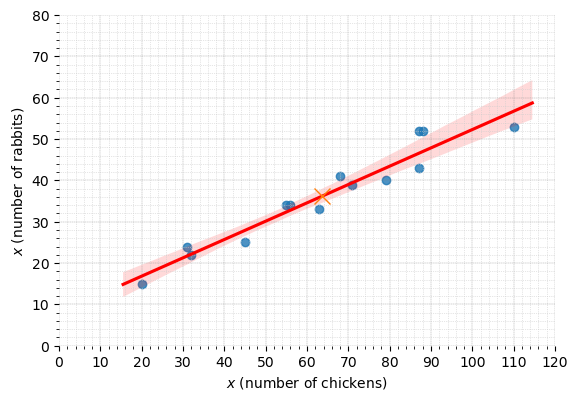

In [98]:
fig,ax = plt.subplots()
#绘制线性回归线 truncate是截断的参数
sns.regplot(x = num_chickens,y = num_rabbits,ax = ax,truncate = False,
            line_kws = {'color':'red'})
plt.plot(mean_X,mean_Y,marker = 'x',markerfacecolor = 'r',markersize = 12)
fig_decor(ax)